<a href="https://colab.research.google.com/github/ignaciovgl/Multi-Asset-Trend-Following-Project/blob/main/Multi_asset_trend_following_backtest_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

We started Week 1 by mapping the planned universe (equity indices, bonds, FX, commodities) onto actual free data sources, and hit a real constraint: yfinance doesn't provide back-adjusted futures for most instruments, and true continuous futures data (properly roll-adjusted) sits behind paid vendors. Rather than forcing a fake solution, we chose a per-instrument hybrid: real futures prices where yfinance actually offers them for free (ZN=F for US 10Y, GC=F/CL=F/HG=F for commodities), and liquid ETF proxies where no free futures exist (IS0L.DE for Bund, IGLT.L for Gilt). We accepted known, documentable tradeoffs on each side — unadjusted roll gaps in the futures series, expense-ratio drag and shorter history in the ETFs — rather than pretending the data is cleaner than it is. Because everything gets converted to daily log returns before any modeling happens, the pipeline itself is source-agnostic; the only thing we need to carry forward is a small metadata table tagging each instrument's source and asset class, so we can apply the right transaction-cost assumption later and flag caveats accurately in the final report.

In [1]:
!pip install yfinance pandas-market-calendars pyarrow -q

from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/trend_following_project'
os.makedirs(f'{PROJECT_DIR}/data/raw', exist_ok=True)
os.makedirs(f'{PROJECT_DIR}/data/processed', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
INSTRUMENT_META = {
    'SPX':    {'ticker': '^GSPC',    'source': 'index',    'asset_class': 'equity'},
    'FTSE':   {'ticker': '^FTSE',    'source': 'index',    'asset_class': 'equity'},
    'DAX':    {'ticker': '^GDAXI',   'source': 'index',    'asset_class': 'equity'},
    'NIKKEI': {'ticker': '^N225',    'source': 'index',    'asset_class': 'equity'},

    'US10Y':  {'ticker': 'ZN=F',     'source': 'futures',  'asset_class': 'bond'},
    'BUND':   {'ticker': 'IS0L.DE',  'source': 'etf',      'asset_class': 'bond'},
    'GILT':   {'ticker': 'IGLT.L',   'source': 'etf',      'asset_class': 'bond'},

    'EURUSD': {'ticker': 'EURUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'GBPUSD': {'ticker': 'GBPUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'USDJPY': {'ticker': 'USDJPY=X', 'source': 'spot_fx',  'asset_class': 'fx'},
    'AUDUSD': {'ticker': 'AUDUSD=X', 'source': 'spot_fx',  'asset_class': 'fx'},

    'GOLD':   {'ticker': 'GC=F',     'source': 'futures',  'asset_class': 'commodity'},
    'CRUDE':  {'ticker': 'CL=F',     'source': 'futures',  'asset_class': 'commodity'},
    'COPPER': {'ticker': 'HG=F',     'source': 'futures',  'asset_class': 'commodity'},
}

import pandas as pd
meta_df = pd.DataFrame(INSTRUMENT_META).T
meta_df.to_csv(f'{PROJECT_DIR}/data/raw/instrument_meta.csv')
meta_df

,ticker,source,asset_class
SPX,^GSPC,index,equity
FTSE,^FTSE,index,equity
DAX,^GDAXI,index,equity
NIKKEI,^N225,index,equity
US10Y,ZN=F,futures,bond
BUND,IS0L.DE,etf,bond
GILT,IGLT.L,etf,bond
EURUSD,EURUSD=X,spot_fx,fx
GBPUSD,GBPUSD=X,spot_fx,fx
USDJPY,USDJPY=X,spot_fx,fx


In [3]:
import yfinance as yf

raw_data = {}
coverage_log = []

for name, meta in INSTRUMENT_META.items():
    ticker = meta['ticker']
    df = yf.download(ticker, start='2000-01-01', progress=False)
    if df.empty:
        print(f'WARNING: no data returned for {name} ({ticker})')
        coverage_log.append({'instrument': name, 'ticker': ticker, 'start': None, 'end': None, 'rows': 0})
        continue

    raw_data[name] = df['Close']
    coverage_log.append({
        'instrument': name, 'ticker': ticker,
        'start': df.index.min().date(), 'end': df.index.max().date(), 'rows': len(df)
    })
    df.to_csv(f'{PROJECT_DIR}/data/raw/{name}.csv')

coverage_df = pd.DataFrame(coverage_log)
coverage_df.to_csv(f'{PROJECT_DIR}/data/raw/coverage_log.csv', index=False)
coverage_df

/tmp/ipykernel_7756/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7756/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7756/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7756/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7756/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start='2000-01-01', progress=False)
/tmp/ipykernel_7756/1743732643.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to 

,instrument,ticker,start,end,rows
0,SPX,^GSPC,2000-01-03,2026-07-13,6670
1,FTSE,^FTSE,2000-01-04,2026-07-13,6700
2,DAX,^GDAXI,2000-01-03,2026-07-13,6735
3,NIKKEI,^N225,2000-01-04,2026-07-13,6497
4,US10Y,ZN=F,2000-09-21,2026-07-13,6479
5,BUND,IS0L.DE,2012-05-08,2026-07-13,3594
6,GILT,IGLT.L,2008-01-02,2026-07-13,4680
7,EURUSD,EURUSD=X,2003-12-01,2026-07-13,5867
8,GBPUSD,GBPUSD=X,2003-12-01,2026-07-13,5879
9,USDJPY,USDJPY=X,2000-01-03,2026-07-13,6887


In [11]:
prices = pd.concat(raw_data, axis=1).sort_index()
prices.to_csv(f'{PROJECT_DIR}/data/raw/prices_combined.csv')
prices.tail()

,SPX,FTSE,DAX,NIKKEI,US10Y,BUND,GILT,EURUSD,GBPUSD,USDJPY,AUDUSD,GOLD,CRUDE,COPPER
Ticker,^GSPC,^FTSE,^GDAXI,^N225,ZN=F,IS0L.DE,IGLT.L,EURUSD=X,GBPUSD=X,USDJPY=X,AUDUSD=X,GC=F,CL=F,HG=F
Date,,,,,,,,,,,,,,
2026-07-07,7503.850098,10665.900391,25465.250000,68256.960938,109.328125,117.290001,9.68250,1.144178,1.339789,162.087997,0.695530,4145.299805,70.440002,6.1715
2026-07-08,7482.709961,10489.000000,24897.449219,66819.046875,109.000000,116.775002,9.59250,1.140381,1.334891,162.363007,0.692260,4070.899902,73.519997,6.0545
2026-07-09,7543.640137,10472.500000,25118.269531,67743.851562,109.265625,116.925003,9.64500,1.142204,1.339621,162.539001,0.693630,4130.600098,72.080002,6.2150
2026-07-10,7575.390137,10497.299805,25067.089844,68557.726562,109.031250,117.019997,9.67000,1.143341,1.341562,162.363007,0.694440,4104.100098,71.410004,6.2335
2026-07-13,7558.649902,10476.910156,25081.539062,67242.726562,108.937500,116.934998,9.62865,1.142988,1.339531,162.134995,0.694541,4069.399902,73.470001,6.3405


In [12]:
# Forward-fill short genuine gaps (holiday mismatches across exchanges),
# but leave pre-inception NaNs alone — don't fabricate history
prices_clean = prices.ffill(limit=5)

nan_report = prices_clean.isna().sum()
print('Remaining NaNs per instrument (should mostly reflect pre-inception gaps):')
print(nan_report)

Remaining NaNs per instrument (should mostly reflect pre-inception gaps):
        Ticker  
SPX     ^GSPC          0
FTSE    ^FTSE          1
DAX     ^GDAXI         0
NIKKEI  ^N225          2
US10Y   ZN=F         190
BUND    IS0L.DE     3221
GILT    IGLT.L      2087
EURUSD  EURUSD=X    1026
GBPUSD  GBPUSD=X    1020
USDJPY  USDJPY=X       6
AUDUSD  AUDUSD=X    1661
GOLD    GC=F         172
CRUDE   CL=F         167
COPPER  HG=F         172
dtype: int64


In [13]:


log_returns = np.log(prices_clean / prices_clean.shift(1))
realised_vol_21d = log_returns.rolling(21).std() * np.sqrt(252)
rolling_corr_63d = log_returns.rolling(63).corr()

log_returns.to_parquet(f'{PROJECT_DIR}/data/processed/log_returns.parquet')
realised_vol_21d.to_parquet(f'{PROJECT_DIR}/data/processed/realised_vol_21d.parquet')
rolling_corr_63d.to_parquet(f'{PROJECT_DIR}/data/processed/rolling_corr_63d.parquet')

print('Saved: log_returns, realised_vol_21d, rolling_corr_63d')

/usr/local/lib/python3.12/dist-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


Saved: log_returns, realised_vol_21d, rolling_corr_63d


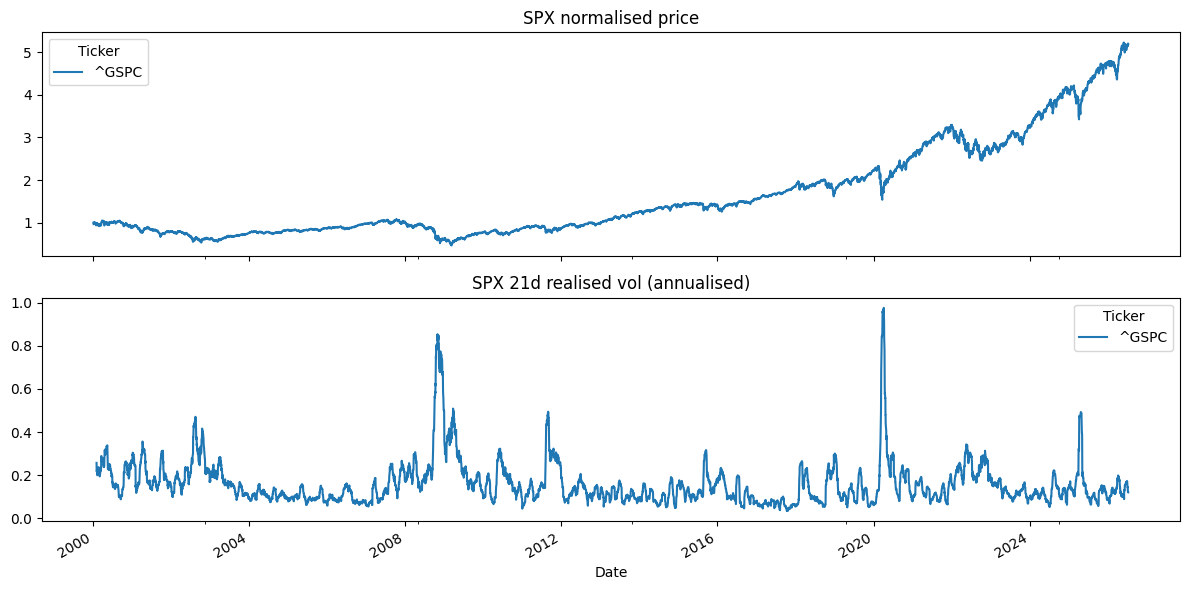

In [14]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
(prices_clean['SPX'] / prices_clean['SPX'].dropna().iloc[0]).plot(ax=axes[0], title='SPX normalised price')
realised_vol_21d['SPX'].plot(ax=axes[1], title='SPX 21d realised vol (annualised)')
plt.tight_layout()
plt.show()